<a href="https://colab.research.google.com/github/Karolsak/advnaced-sieci/blob/claude%2Fpower-system-ode-solver-gui-011CV6Gg5ZcpsQ1MJkebuExe/Python_%2B_Tkinter_Motor_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
import math

# Check for matplotlib. If not found, the dynamic graph will be disabled.
try:
    import matplotlib
    matplotlib.use("TkAgg")
    from matplotlib.figure import Figure
    from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

class MotorLabApp(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Advanced Series Motor Simulation Lab")
        self.geometry("1000x800")
        self.minsize(600, 400)

        # --- Class Variables ---
        self.simulation_running = False
        self.simulation_time = 0
        self.simulation_job = None

        # --- Configure Main Window Grid (for autoscaling) ---
        self.grid_rowconfigure(0, weight=1)
        self.grid_columnconfigure(0, weight=1)

        # --- Create Main Notebook (Tabs) ---
        self.notebook = ttk.Notebook(self)
        self.notebook.grid(row=0, column=0, sticky="nsew", padx=10, pady=10)

        # --- Create Tabs ---
        self.tab_solver = ttk.Frame(self.notebook)
        self.tab_dynamic_sim = ttk.Frame(self.notebook)
        self.tab_controls = ttk.Frame(self.notebook)
        self.tab_multiphysics = ttk.Frame(self.notebook)
        self.tab_economic = ttk.Frame(self.notebook)

        self.notebook.add(self.tab_solver, text="Problem Solver (Ex. 30.45)")
        self.notebook.add(self.tab_dynamic_sim, text="Dynamic Simulation")
        self.notebook.add(self.tab_controls, text="Advanced Controls")
        self.notebook.add(self.tab_multiphysics, text="Multi-Physics Analysis")
        self.notebook.add(self.tab_economic, text="Economic Analysis")

        # --- Populate Each Tab ---
        self.create_solver_tab()
        self.create_dynamic_sim_tab()
        self.create_controls_tab()
        self.create_multiphysics_tab()
        self.create_economic_tab()

    # ----------------------------------------------------------------------
    # TAB 1: STEADY-STATE PROBLEM SOLVER
    # ----------------------------------------------------------------------
    def create_solver_tab(self):
        """Creates the UI for the specific problem solver."""
        # Configure grid for autoscaling
        self.tab_solver.grid_columnconfigure(1, weight=1)
        self.tab_solver.grid_columnconfigure(3, weight=1)

        # --- Title ---
        title = ttk.Label(self.tab_solver, text="Steady-State Solver for Two Series Motors", font=("Inter", 16, "bold"))
        title.grid(row=0, column=0, columnspan=4, pady=10, padx=10)

        desc = ttk.Label(self.tab_solver, text="Solves the specific problem (Ex. 30.45) based on idealized assumptions (no losses, unsaturated).", wraplength=800)
        desc.grid(row=1, column=0, columnspan=4, pady=(0, 15), padx=10)

        # --- Input Frame ---
        input_frame = ttk.LabelFrame(self.tab_solver, text="Motor & System Parameters")
        input_frame.grid(row=2, column=0, columnspan=4, sticky="ew", padx=10, pady=5)
        input_frame.grid_columnconfigure(1, weight=1)
        input_frame.grid_columnconfigure(3, weight=1)

        self.params = {} # Dictionary to hold Entry widgets

        # Column 0
        ttk.Label(input_frame, text="Rated Power (kW):").grid(row=0, column=0, sticky="w", padx=10, pady=5)
        self.params["power"] = ttk.Entry(input_frame)
        self.params["power"].grid(row=0, column=1, sticky="ew", padx=10, pady=5)
        self.params["power"].insert(0, "14.92")

        ttk.Label(input_frame, text="Rated Voltage (V):").grid(row=1, column=0, sticky="w", padx=10, pady=5)
        self.params["v_rated"] = ttk.Entry(input_frame)
        self.params["v_rated"].grid(row=1, column=1, sticky="ew", padx=10, pady=5)
        self.params["v_rated"].insert(0, "250")

        ttk.Label(input_frame, text="Rated Speed (rpm):").grid(row=2, column=0, sticky="w", padx=10, pady=5)
        self.params["n_rated"] = ttk.Entry(input_frame)
        self.params["n_rated"].grid(row=2, column=1, sticky="ew", padx=10, pady=5)
        self.params["n_rated"].insert(0, "1000")

        # Column 2
        ttk.Label(input_frame, text="Total Supply Voltage (V):").grid(row=0, column=2, sticky="w", padx=10, pady=5)
        self.params["v_supply"] = ttk.Entry(input_frame)
        self.params["v_supply"].grid(row=0, column=3, sticky="ew", padx=10, pady=5)
        self.params["v_supply"].insert(0, "250")

        ttk.Label(input_frame, text="Total Load Torque (N-m):").grid(row=1, column=2, sticky="w", padx=10, pady=5)
        self.params["t_shaft"] = ttk.Entry(input_frame)
        self.params["t_shaft"].grid(row=1, column=3, sticky="ew", padx=10, pady=5)
        self.params["t_shaft"].insert(0, "882")

        ttk.Label(input_frame, text="Gear Ratios (G1, G2):").grid(row=2, column=2, sticky="w", padx=10, pady=5)
        self.params["gear_ratios"] = ttk.Entry(input_frame)
        self.params["gear_ratios"].grid(row=2, column=3, sticky="ew", padx=10, pady=5)
        self.params["gear_ratios"].insert(0, "5, 4")

        # --- Calculate Button ---
        calc_button = ttk.Button(self.tab_solver, text="Calculate Solution", command=self.calculate_static_solution)
        calc_button.grid(row=3, column=0, columnspan=4, pady=15)

        # --- Results Frame ---
        results_frame = ttk.LabelFrame(self.tab_solver, text="Calculated Results")
        results_frame.grid(row=4, column=0, columnspan=4, sticky="ew", padx=10, pady=5)
        results_frame.grid_columnconfigure(1, weight=1)
        results_frame.grid_columnconfigure(3, weight=1)

        self.results = {} # Dictionary to hold result Labels

        # (i) Current
        ttk.Label(results_frame, text="Total Supply Current (I):", font=("Inter", 10, "bold")).grid(row=0, column=0, sticky="w", padx=10, pady=8)
        self.results["current"] = ttk.Label(results_frame, text="--- A", font=("Inter", 10, "bold"), foreground="blue")
        self.results["current"].grid(row=0, column=1, sticky="w", padx=10, pady=8)

        # (ii) Shaft Speed
        ttk.Label(results_frame, text="Load Shaft Speed (N_shaft):", font=("Inter", 10, "bold")).grid(row=0, column=2, sticky="w", padx=10, pady=8)
        self.results["shaft_speed"] = ttk.Label(results_frame, text="--- rpm", font=("Inter", 10, "bold"), foreground="blue")
        self.results["shaft_speed"].grid(row=0, column=3, sticky="w", padx=10, pady=8)

        # (iii) Voltages
        ttk.Label(results_frame, text="Voltage Motor 1 (V1):").grid(row=1, column=0, sticky="w", padx=10, pady=8)
        self.results["v1"] = ttk.Label(results_frame, text="--- V", foreground="blue")
        self.results["v1"].grid(row=1, column=1, sticky="w", padx=10, pady=8)

        ttk.Label(results_frame, text="Voltage Motor 2 (V2):").grid(row=2, column=0, sticky="w", padx=10, pady=8)
        self.results["v2"] = ttk.Label(results_frame, text="--- V", foreground="blue")
        self.results["v2"].grid(row=2, column=1, sticky="w", padx=10, pady=8)

        # (Other)
        ttk.Label(results_frame, text="Speed Motor 1 (N1):").grid(row=1, column=2, sticky="w", padx=10, pady=8)
        self.results["n1"] = ttk.Label(results_frame, text="--- rpm")
        self.results["n1"].grid(row=1, column=3, sticky="w", padx=10, pady=8)

        ttk.Label(results_frame, text="Speed Motor 2 (N2):").grid(row=2, column=2, sticky="w", padx=10, pady=8)
        self.results["n2"] = ttk.Label(results_frame, text="--- rpm")
        self.results["n2"].grid(row=2, column=3, sticky="w", padx=10, pady=8)

        # --- Log/Explanation Frame ---
        log_frame = ttk.LabelFrame(self.tab_solver, text="Calculation Steps")
        log_frame.grid(row=5, column=0, columnspan=4, sticky="nsew", padx=10, pady=10)
        self.tab_solver.grid_rowconfigure(5, weight=1) # Make log frame expand

        self.log_text = tk.Text(log_frame, height=10, wrap="word", state="disabled")
        log_scroll = ttk.Scrollbar(log_frame, orient="vertical", command=self.log_text.yview)
        self.log_text.config(yscrollcommand=log_scroll.set)

        log_scroll.pack(side="right", fill="y")
        self.log_text.pack(side="left", fill="both", expand=True, padx=5, pady=5)

    def log_message(self, message):
        """Helper to add messages to the log window."""
        self.log_text.config(state="normal")
        self.log_text.insert("end", message + "\n")
        self.log_text.see("end")
        self.log_text.config(state="disabled")

    def calculate_static_solution(self):
        """Performs the algebraic calculation."""
        self.log_text.config(state="normal")
        self.log_text.delete("1.0", "end")
        self.log_message("--- Calculation Started ---")
        try:
            # 1. Get all parameters
            P_rated = float(self.params["power"].get()) * 1000  # W
            V_rated = float(self.params["v_rated"].get())       # V
            N_rated = float(self.params["n_rated"].get())       # rpm
            V_supply = float(self.params["v_supply"].get())     # V
            T_shaft = float(self.params["t_shaft"].get())       # N-m
            gears = self.params["gear_ratios"].get().split(',')
            G1 = float(gears[0])
            G2 = float(gears[1])

            self.log_message(f"Inputs: P_rated={P_rated/1000}kW, V_rated={V_rated}V, N_rated={N_rated}rpm")
            self.log_message(f"System: V_supply={V_supply}V, T_shaft={T_shaft}N-m, G1={G1}, G2={G2}")

            # 2. Calculate rated-point constants (assuming P_out = P_in)
            # P = T * w. w_rated = N_rated * 2pi/60
            w_rated = N_rated * 2 * math.pi / 60
            T_rated = P_rated / w_rated

            # P_in = V * I -> I_rated = P_rated / V_rated (since losses=0)
            I_rated = P_rated / V_rated
            self.log_message(f"Calculated Rated: I_rated={I_rated:.2f} A, T_rated={T_rated:.2f} N-m")

            # 3. Find motor constants K_T and K_e
            # T = K_T * I^2
            K_T = T_rated / (I_rated**2)
            # V = Eb = K_e * I * N (since R_a=0)
            K_e = V_rated / (I_rated * N_rated)
            self.log_message(f"Motor Constants: K_T={K_T:.5f}, K_e={K_e:.5f}")

            # 4. Solve for the operating condition
            # T_shaft = T_m1*G1 + T_m2*G2
            # Since motors are identical and in series, I1=I2=I, so T_m1=T_m2=T_m
            # T_m = K_T * I^2
            # T_shaft = T_m * (G1 + G2)
            # T_m = T_shaft / (G1 + G2)
            T_m = T_shaft / (G1 + G2)
            self.log_message(f"Required motor torque T_m = {T_shaft} / ({G1} + {G2}) = {T_m:.2f} N-m")

            # 5. (i) Find Current (I)
            # T_m = K_T * I^2 -> I = sqrt(T_m / K_T)
            I = math.sqrt(T_m / K_T)
            self.log_message(f"Supply Current I = sqrt({T_m:.2f} / {K_T:.5f}) = {I:.2f} A")

            # 6. Find Voltages
            # N1 = G1 * N_shaft, N2 = G2 * N_shaft
            # N1 / N2 = G1 / G2
            # V1 = K_e * I * N1, V2 = K_e * I * N2
            # V1 / V2 = (K_e*I*N1) / (K_e*I*N2) = N1 / N2 = G1 / G2
            # V1 = V2 * (G1 / G2)
            # V_supply = V1 + V2 = V2 * (G1/G2) + V2 = V2 * (1 + G1/G2)
            V2 = V_supply / (1 + (G1 / G2))
            V1 = V_supply - V2
            self.log_message(f"Voltage ratio V1/V2 = N1/N2 = {G1}/{G2} = {G1/G2:.2f}")
            self.log_message(f"V2 = {V_supply} / (1 + {G1/G2:.2f}) = {V2:.2f} V")
            self.log_message(f"V1 = {V_supply} - {V2:.2f} = {V1:.2f} V")

            # 7. (ii) Find Speeds
            # V2 = K_e * I * N2
            N2 = V2 / (K_e * I)
            # V1 = K_e * I * N1
            N1 = V1 / (K_e * I)
            self.log_message(f"Motor Speed N2 = {V2:.2f} / ({K_e:.5f} * {I:.2f}) = {N2:.2f} rpm")
            self.log_message(f"Motor Speed N1 = {V1:.2f} / ({K_e:.5f} * {I:.2f}) = {N1:.2f} rpm")

            # N_shaft = N2 / G2
            N_shaft = N2 / G2
            # Check with N1: N_shaft = N1 / G1
            N_shaft_check = N1 / G1
            self.log_message(f"Shaft Speed = {N2:.2f} / {G2} = {N_shaft:.2f} rpm")
            self.log_message(f"(Check: {N1:.2f} / {G1} = {N_shaft_check:.2f} rpm)")

            # 8. Update Results
            self.results["current"].config(text=f"{I:.2f} A")
            self.results["shaft_speed"].config(text=f"{N_shaft:.2f} rpm")
            self.results["v1"].config(text=f"{V1:.2f} V")
            self.results["v2"].config(text=f"{V2:.2f} V")
            self.results["n1"].config(text=f"{N1:.2f} rpm")
            self.results["n2"].config(text=f"{N2:.2f} rpm")

            self.log_message("--- Calculation Complete ---")

        except ValueError as e:
            messagebox.showerror("Input Error", f"Invalid input. Please check parameters. \nError: {e}")
            self.log_message(f"ERROR: {e}")
        except Exception as e:
            messagebox.showerror("Error", f"An unexpected error occurred: {e}")
            self.log_message(f"ERROR: {e}")
        finally:
            self.log_text.config(state="disabled")

    # ----------------------------------------------------------------------
    # TAB 2: DYNAMIC SIMULATION
    # ----------------------------------------------------------------------
    def create_dynamic_sim_tab(self):
        """Creates the UI for the dynamic simulation tab."""
        # Configure grid
        self.tab_dynamic_sim.grid_columnconfigure(0, weight=1)
        self.tab_dynamic_sim.grid_rowconfigure(1, weight=1)

        # --- Control Frame ---
        control_frame = ttk.Frame(self.tab_dynamic_sim)
        control_frame.grid(row=0, column=0, sticky="ew", padx=10, pady=10)

        self.start_button = ttk.Button(control_frame, text="Start Simulation", command=self.toggle_simulation)
        self.start_button.pack(side="left", padx=5)

        self.reset_button = ttk.Button(control_frame, text="Reset", command=self.reset_simulation)
        self.reset_button.pack(side="left", padx=5)

        self.sim_status_label = ttk.Label(control_frame, text="Status: Idle", font=("Inter", 10, "italic"))
        self.sim_status_label.pack(side="left", padx=15)

        # --- Plot Frame ---
        plot_frame = ttk.LabelFrame(self.tab_dynamic_sim, text="Live Simulation Graph")
        plot_frame.grid(row=1, column=0, sticky="nsew", padx=10, pady=5)
        plot_frame.grid_rowconfigure(0, weight=1)
        plot_frame.grid_columnconfigure(0, weight=1)

        if MATPLOTLIB_AVAILABLE:
            self.fig = Figure(figsize=(5, 4), dpi=100)
            self.ax1 = self.fig.add_subplot(211)
            self.ax2 = self.fig.add_subplot(212, sharex=self.ax1)

            self.ax1.set_title("Motor Speed (rpm)")
            self.ax1.set_ylabel("Speed (rpm)")
            self.ax1.grid(True)

            self.ax2.set_title("Armature Current (A)")
            self.ax2.set_xlabel("Time (s)")
            self.ax2.set_ylabel("Current (A)")
            self.ax2.grid(True)

            self.fig.tight_layout()

            self.canvas = FigureCanvasTkAgg(self.fig, master=plot_frame)
            self.canvas.get_tk_widget().grid(row=0, column=0, sticky="nsew")
            self.canvas.draw()

            # Data storage
            self.time_data = []
            self.speed_data = []
            self.current_data = []

            self.line_speed, = self.ax1.plot([], [], 'r-')
            self.line_current, = self.ax2.plot([], [], 'b-')

        else:
            # Placeholder if matplotlib is not installed
            error_label = ttk.Label(plot_frame,
                text="Matplotlib not found.\nDynamic plotting is disabled.\nInstall with 'pip install matplotlib'",
                font=("Inter", 12), foreground="red")
            error_label.grid(row=0, column=0, sticky="nsew")

    def toggle_simulation(self):
        if self.simulation_running:
            self.stop_simulation()
        else:
            self.start_simulation()

    def start_simulation(self):
        if not MATPLOTLIB_AVAILABLE:
            messagebox.showinfo("Simulation Error", "Cannot start simulation. Matplotlib library not found.")
            return

        self.simulation_running = True
        self.start_button.config(text="Stop Simulation")
        self.sim_status_label.config(text="Status: Running...", foreground="green")
        self.run_simulation_step()

    def stop_simulation(self):
        self.simulation_running = False
        if self.simulation_job:
            self.after_cancel(self.simulation_job)
            self.simulation_job = None
        self.start_button.config(text="Start Simulation")
        self.sim_status_label.config(text="Status: Stopped", foreground="red")

    def reset_simulation(self):
        self.stop_simulation()
        self.simulation_time = 0
        self.time_data = []
        self.speed_data = []
        self.current_data = []

        if MATPLOTLIB_AVAILABLE:
            self.line_speed.set_data([], [])
            self.line_current.set_data([], [])
            self.ax1.relim()
            self.ax1.autoscale_view()
            self.ax2.relim()
            self.ax2.autoscale_view()
            self.canvas.draw()

        self.sim_status_label.config(text="Status: Idle", foreground="black")

    def run_simulation_step(self):
        if not self.simulation_running:
            return

        # --- This is a FAKE simulation step ---
        # A real solver (e.g., RK45) would go here, solving:
        # 1. dI/dt = (V_supply - Eb - I*(Ra_total)) / La_total
        # 2. d(w)/dt = (T_m_total - T_load_on_motor_shaft) / J_total
        # Where:
        # Eb = K_e_total * I * w
        # T_m = K_T_total * I^2
        # T_load_on_motor_shaft = T_shaft_load / G_total
        # This requires R, L, J, B (friction) parameters, which we don't have.

        # We will generate "plausible" startup data instead.
        t = self.simulation_time
        # Plausible speed: N_final * (1 - exp(-t/tau))
        # Plausible current: I_stall * exp(-t/tau) + I_steady_state
        N_final = 134.0 # From our static solver
        I_steady = 49.5 # From our static solver
        I_stall = 150 # Guessed stall current
        tau = 1.5 # Guessed time constant

        # Use shaft speed for N_final
        speed = N_final * (1 - math.exp(-t / tau)) + np.random.rand()*2-1
        current = (I_stall - I_steady) * math.exp(-t / tau) + I_steady + np.random.rand()*3-1.5

        if t > 5: # Level off after 5 seconds
            speed = N_final + np.random.rand()*2-1
            current = I_steady + np.random.rand()*3-1.5

        self.time_data.append(t)
        self.speed_data.append(speed)
        self.current_data.append(current)

        # Update plot
        self.line_speed.set_data(self.time_data, self.speed_data)
        self.line_current.set_data(self.time_data, self.current_data)

        self.ax1.relim()
        self.ax1.autoscale_view(True, True)
        self.ax2.relim()
        self.ax2.autoscale_view(True, True)

        self.canvas.draw()

        self.simulation_time += 0.1 # 100ms update interval
        self.simulation_job = self.after(100, self.run_simulation_step)


    # ----------------------------------------------------------------------
    # TAB 3: ADVANCED CONTROLS
    # ----------------------------------------------------------------------
    def create_controls_tab(self):
        """Creates the UI for the advanced controls tab."""
        text_frame = ttk.Frame(self.tab_controls, padding=15)
        text_frame.pack(fill="both", expand=True)

        text_frame.grid_columnconfigure(0, weight=1)
        text_frame.grid_rowconfigure(0, weight=1)

        text_widget = tk.Text(text_frame, wrap="word", font=("Inter", 10))
        text_widget.grid(row=0, column=0, sticky="nsew")

        scroll = ttk.Scrollbar(text_frame, orient="vertical", command=text_widget.yview)
        scroll.grid(row=0, column=1, sticky="ns")
        text_widget.config(yscrollcommand=scroll.set)

        text_widget.insert("1.0", "Advanced Machine Control Methods\n\n", ("h1",))
        text_widget.insert("end", "This section would model various control strategies for DC series motors, which are crucial for managing speed and torque under different loads.\n\n")

        text_widget.insert("end", "1. Armature Voltage Control (Chopper Control):\n", ("h2",))
        text_widget.insert("end", "A DC-DC converter (chopper) varies the average voltage applied to the motor armature. By controlling the duty cycle (D) of the chopper, the voltage V_a = D * V_supply is adjusted. This provides smooth speed control below the base speed. This is the most common modern method for DC motor control.\n\n")

        text_widget.insert("end", "2. Field Control (Field Diverter):\n", ("h2",))
        text_widget.insert("end", "A variable resistor is connected in parallel with the series field. This 'diverts' some of the armature current away from the field, weakening the flux (Φ). Since Speed ∝ Eb / Φ, reducing Φ increases the speed. This method is used for achieving speeds *above* the base speed (field weakening).\n\n")

        text_widget.insert("end", "3. Armature Resistance Control:\n", ("h2",))
        text_widget.insert("end", "A variable resistor is added in series with the armature. This is a simple but highly inefficient method. It controls speed by increasing the voltage drop (I*R). Most of the power is wasted as heat in the resistor (P_loss = I² * R_ext). This is generally only used for starting (as a 'starter') to limit inrush current, not for continuous speed control.\n\n")

        text_widget.insert("end", "Dynamic models for these controls would involve adding their respective differential equations or logic (e.g., chopper duty cycle) to the main ODE solver.\n")

        text_widget.tag_config("h1", font=("Inter", 16, "bold"), underline=True)
        text_widget.tag_config("h2", font=("Inter", 12, "bold"))
        text_widget.config(state="disabled")

    # ----------------------------------------------------------------------
    # TAB 4: MULTI-PHYSICS ANALYSIS
    # ----------------------------------------------------------------------
    def create_multiphysics_tab(self):
        """Creates the UI for the multi-physics tab."""
        text_frame = ttk.Frame(self.tab_multiphysics, padding=15)
        text_frame.pack(fill="both", expand=True)

        text_frame.grid_columnconfigure(0, weight=1)
        text_frame.grid_rowconfigure(0, weight=1)

        text_widget = tk.Text(text_frame, wrap="word", font=("Inter", 10))
        text_widget.grid(row=0, column=0, sticky="nsew")

        scroll = ttk.Scrollbar(text_frame, orient="vertical", command=text_widget.yview)
        scroll.grid(row=0, column=1, sticky="ns")
        text_widget.config(yscrollcommand=scroll.set)

        text_widget.insert("1.0", "Multi-Physics Simulation Concepts\n\n", ("h1",))
        text_widget.insert("end", "A truly advanced simulation couples electrical, thermal, and mechanical models. The idealized solver in Tab 1 neglects these, but a real-world model must include them.\n\n")

        text_widget.insert("end", "1. Coupled Electromagnetic-Thermal Model:\n", ("h2",))
        text_widget.insert("end", " •  Electrical Model -> Thermal Model: The electrical model calculates losses (I²R_a, I²R_f, iron losses, etc.). These losses are the heat sources (Q_in) for the thermal model.\n")
        text_widget.insert("end", " •  Thermal Model: Solves the heat transfer equation: d(Temp)/dt = (Q_in - Q_out) / C_th, where C_th is thermal capacitance and Q_out is heat dissipated to the environment (proportional to Temp - T_ambient).\n")
        text_widget.insert("end", " •  Thermal Model -> Electrical Model (Derating): The motor's resistances (R_a, R_f) are functions of temperature: R(T) = R_ref * (1 + α * (T - T_ref)). As the motor heats up, R increases, which in turn increases I²R losses (thermal runaway) or reduces current/torque. This is 'derating'.\n\n")

        text_widget.insert("end", "2. Mechanical Stress Analysis:\n", ("h2",))
        text_widget.insert("end", " •  Shaft Torque Transients: During startup, the current (and thus torque) is very high (I_stall). The ODE solver for mechanics (d(w)/dt) would show this 'torque transient' or 'jerk', which causes mechanical stress on the shaft and gears.\n")
        text.insert("end", " •  Bearing Loads: The model would calculate radial and axial forces on the bearings, especially important in geared systems.\n\n")

        text_widget.insert("end", "3. Detailed Loss Breakdown (Power Consumption):\n", ("h2",))
        text_widget.insert("end", "A full simulation tracks power flow and separates losses:\n")
        text_widget.insert("end", " •  Copper Losses (P_cu): I_a² * R_a + I_f² * R_f. The dominant loss, dependent on load and temperature.\n")
        text_widget.insert("end", " •  Iron Losses (P_core): Hysteresis and eddy current losses in the core. Proportional to B² (flux) and speed (N). Significant at high speed/no-load.\n")
        text_widget.insert("end", " •  Mechanical Losses (P_mech): Friction in bearings and windage (air drag). Proportional to speed (B*w or C*N²).\n")
        text_widget.insert("end", " •  Stray Load Losses: Other complex losses. Often modeled as a fixed percentage.\n")
        text_widget.insert("end", " •  Efficiency (η) = P_out / P_in = P_out / (P_out + P_cu + P_core + P_mech + P_stray)\n")

        text_widget.tag_config("h1", font=("Inter", 16, "bold"), underline=True)
        text_widget.tag_config("h2", font=("Inter", 12, "bold"))
        text_widget.config(state="disabled")

    # ----------------------------------------------------------------------
    # TAB 5: ECONOMIC ANALYSIS
    # ----------------------------------------------------------------------
    def create_economic_tab(self):
        """Creates the UI for the economic analysis tab."""
        text_frame = ttk.Frame(self.tab_economic, padding=15)
        text_frame.pack(fill="both", expand=True)

        text_frame.grid_columnconfigure(0, weight=1)
        text_frame.grid_rowconfigure(0, weight=1)

        text_widget = tk.Text(text_frame, wrap="word", font=("Inter", 10))
        text_widget.grid(row=0, column=0, sticky="nsew")

        scroll = ttk.Scrollbar(text_frame, orient="vertical", command=text_widget.yview)
        scroll.grid(row=0, column=1, sticky="ns")
        text_widget.config(yscrollcommand=scroll.set)

        text_widget.insert("1.0", "Economic Analysis Framework\n\n", ("h1",))
        text_widget.insert("end", "This module would analyze the financial viability and operational costs of the motor system.\n\n")

        text_widget.insert("end", "1. Capital Expenditure (CapEx):\n", ("h2",))
        text_widget.insert("end", " •  Initial purchase cost of motors, gearing, and control electronics (e.g., choppers).\n\n")

        text_widget.insert("end", "2. Operational Expenditure (OpEx) - Power Consumption:\n", ("h2",))
        text_widget.insert("end", " •  The most significant ongoing cost. This requires the detailed loss model from the Multi-Physics tab.\n")
        text_widget.insert("end", " •  Input Power (P_in) = V_supply * I\n")
        text_widget.insert("end", " •  Energy (kWh) = P_in (kW) * time (hours)\n")
        text_widget.insert("end", " •  Cost = Energy (kWh) * Electricity Rate ($/kWh)\n")
        text_widget.insert("end", " •  A simulation would run a 'load profile' (e.g., 50% load for 4 hours, 100% load for 2 hours, idle for 2 hours) to calculate total daily energy consumption.\n\n")

        text_widget.insert("end", "3. Lifecycle Cost (LCC):\n", ("h2",))
        text_widget.insert("end",This would be the output from the "Advanced Controls" tab, which would include models for different control strategies like chopper control, field weakening, and armature resistance control.
 " •  LCC = CapEx + (Sum of OpEx over lifetime) + (Sum of Maintenance Costs over lifetime)\n")
        text_widget.insert("end", " •  Maintenance: Cost of replacing brushes (DC motors), bearings, etc. The thermal model can predict lifetime (high temps drastically reduce insulation and bearing life).\n\n")

        text_widget.insert("end", "4. Payback Period & ROI:\n", ("h2",))
        text_widget.insert("end", " •  Compares a high-efficiency motor (higher CapEx, lower OpEx) vs. a standard motor (lower CapEx, higher OpEx).\n")
        text_widget.insert("end", " •  Payback Period = (CapEx_High - CapEx_Low) / (OpEx_Low - OpEx_High)\n")

        text_widget.tag_config("h1", font=("Inter", 16, "bold"), underline=True)
        text_widget.tag_config("h2", font=("Inter", 12, "bold"))
        text_widget.config(state="disabled")

if __name__ == "__main__":
    app = MotorLabApp()
    app.mainloop()

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import math
import io
import contextlib

# Matplotlib setup for dynamic simulation (will be used in a later tab)
try:
    import matplotlib.pyplot as plt
    # %matplotlib inline # Or %matplotlib widget for interactive plots
    # Use 'widget' backend if available for interactive ipywidgets plots
    try:
        import ipympl.backend_nbagg # Required for %matplotlib widget
        MATPLOTLIB_AVAILABLE = True
        MATPLOTLIB_BACKEND = 'widget'
    except ImportError:
        MATPLOTLIB_AVAILABLE = True
        MATPLOTLIB_BACKEND = 'inline' # Fallback to inline if ipympl not found
    print(f"Matplotlib available. Backend: {MATPLOTLIB_BACKEND}")
except ImportError:
    MATPLOTLIB_AVAILABLE = False
    print("Matplotlib not found. Dynamic plotting will be disabled.")

Matplotlib available. Backend: inline


In [8]:
class MotorLabWidgetsApp:
    def __init__(self):
        self.simulation_running = False
        self.simulation_time = 0
        self.simulation_job = None # To hold the display update job if needed

        # --- Create Main Notebook (Tabs) ---
        self.tab_solver = widgets.Output() # Using Output widgets for tab content
        self.tab_dynamic_sim = widgets.Output()
        self.tab_controls = widgets.Output()
        self.tab_multiphysics = widgets.Output()
        self.tab_economic = widgets.Output()

        self.notebook = widgets.Tab()
        self.notebook.children = [
            self.tab_solver,
            self.tab_dynamic_sim,
            self.tab_controls,
            self.tab_multiphysics,
            self.tab_economic
        ]

        self.notebook.set_title(0, 'Problem Solver (Ex. 30.45)')
        self.notebook.set_title(1, 'Dynamic Simulation')
        self.notebook.set_title(2, 'Advanced Controls')
        self.notebook.set_title(3, 'Multi-Physics Analysis')
        self.notebook.set_title(4, 'Economic Analysis')

        # --- Populate Each Tab ---
        self.create_solver_tab()
        self.create_dynamic_sim_tab()
        self.create_controls_tab()
        self.create_multiphysics_tab()
        self.create_economic_tab()

    def create_solver_tab(self):
        with self.tab_solver:
            clear_output(wait=True)
            # --- Title ---
            title = widgets.HTML('<h2 style="font-family: Inter; font-weight: bold;">Steady-State Solver for Two Series Motors</h2>')
            desc = widgets.HTML('<p style="font-family: Inter;">Solves the specific problem (Ex. 30.45) based on idealized assumptions (no losses, unsaturated).</p>')

            # --- Input Frame ---
            self.params = {
                "power": widgets.FloatText(description="Rated Power (kW):", value=14.92, layout=widgets.Layout(width='auto')),
                "v_rated": widgets.FloatText(description="Rated Voltage (V):", value=250.0, layout=widgets.Layout(width='auto')),
                "n_rated": widgets.FloatText(description="Rated Speed (rpm):", value=1000.0, layout=widgets.Layout(width='auto')),
                "v_supply": widgets.FloatText(description="Total Supply Voltage (V):", value=250.0, layout=widgets.Layout(width='auto')),
                "t_shaft": widgets.FloatText(description="Total Load Torque (N-m):", value=882.0, layout=widgets.Layout(width='auto')),
                "gear_ratios": widgets.Text(description="Gear Ratios (G1, G2):", value="5, 4", layout=widgets.Layout(width='auto'))
            }

            input_items_left = [
                self.params["power"],
                self.params["v_rated"],
                self.params["n_rated"]
            ]
            input_items_right = [
                self.params["v_supply"],
                self.params["t_shaft"],
                self.params["gear_ratios"]
            ]

            input_grid = widgets.GridBox(
                input_items_left + input_items_right,
                layout=widgets.Layout(
                    width='100%',
                    grid_template_columns='repeat(2, 1fr)',
                    grid_gap='10px'
                )
            )
            input_frame_label = widgets.HTML('<b>Motor & System Parameters</b>')
            input_frame = widgets.VBox([input_frame_label, input_grid], layout=widgets.Layout(border='1px solid lightgray', padding='10px', margin='10px 0'))

            # --- Calculate Button ---
            calc_button = widgets.Button(description="Calculate Solution", button_style='info', layout=widgets.Layout(width='auto'))
            calc_button.on_click(self.calculate_static_solution)

            # --- Results Frame ---
            self.results = {
                "current": widgets.HTML("--- A"),
                "shaft_speed": widgets.HTML("--- rpm"),
                "v1": widgets.HTML("--- V"),
                "v2": widgets.HTML("--- V"),
                "n1": widgets.HTML("--- rpm"),
                "n2": widgets.HTML("--- rpm")
            }

            results_grid_items = [
                widgets.HTML('<b>Total Supply Current (I):</b>'), self.results["current"],
                widgets.HTML('<b>Load Shaft Speed (N_shaft):</b>'), self.results["shaft_speed"],
                widgets.HTML('Voltage Motor 1 (V1):'), self.results["v1"],
                widgets.HTML('Speed Motor 1 (N1):'), self.results["n1"],
                widgets.HTML('Voltage Motor 2 (V2):'), self.results["v2"],
                widgets.HTML('Speed Motor 2 (N2):'), self.results["n2"]
            ]

            results_grid = widgets.GridBox(
                results_grid_items,
                layout=widgets.Layout(
                    width='100%',
                    grid_template_columns='repeat(4, auto)', # Auto for labels, 1fr for values
                    grid_column_gap='10px',
                    grid_row_gap='8px'
                )
            )
            results_frame_label = widgets.HTML('<b>Calculated Results</b>')
            results_frame = widgets.VBox([results_frame_label, results_grid], layout=widgets.Layout(border='1px solid lightgray', padding='10px', margin='10px 0'))

            # --- Log/Explanation Frame ---
            self.log_output = widgets.Output(layout={'border': '1px solid black', 'height': '150px', 'overflow_y': 'scroll'})
            log_frame_label = widgets.HTML('<b>Calculation Steps</b>')
            log_frame = widgets.VBox([log_frame_label, self.log_output], layout=widgets.Layout(border='1px solid lightgray', padding='10px', margin='10px 0'))

            display(widgets.VBox([title, desc, input_frame, calc_button, results_frame, log_frame]))

    def log_message(self, message):
        """Helper to add messages to the log output widget."""
        with self.log_output:
            print(message)

    def calculate_static_solution(self, b):
        """Performs the algebraic calculation."""
        with self.log_output:
            clear_output(wait=True) # Clear previous log messages
            print("--- Calculation Started ---")
        try:
            # 1. Get all parameters
            P_rated = self.params["power"].value * 1000  # W
            V_rated = self.params["v_rated"].value       # V
            N_rated = self.params["n_rated"].value       # rpm
            V_supply = self.params["v_supply"].value     # V
            T_shaft = self.params["t_shaft"].value       # N-m
            gears_str = self.params["gear_ratios"].value.split(',')
            G1 = float(gears_str[0].strip())
            G2 = float(gears_str[1].strip())

            self.log_message(f"Inputs: P_rated={P_rated/1000}kW, V_rated={V_rated}V, N_rated={N_rated}rpm")
            self.log_message(f"System: V_supply={V_supply}V, T_shaft={T_shaft}N-m, G1={G1}, G2={G2}")

            # 2. Calculate rated-point constants (assuming P_out = P_in)
            w_rated = N_rated * 2 * math.pi / 60
            T_rated = P_rated / w_rated

            I_rated = P_rated / V_rated
            self.log_message(f"Calculated Rated: I_rated={I_rated:.2f} A, T_rated={T_rated:.2f} N-m")

            # 3. Find motor constants K_T and K_e
            K_T = T_rated / (I_rated**2)
            K_e = V_rated / (I_rated * N_rated)
            self.log_message(f"Motor Constants: K_T={K_T:.5f}, K_e={K_e:.5f}")

            # 4. Solve for the operating condition
            T_m = T_shaft / (G1 + G2)
            self.log_message(f"Required motor torque T_m = {T_shaft} / ({G1} + {G2}) = {T_m:.2f} N-m")

            # 5. (i) Find Current (I)
            I = math.sqrt(T_m / K_T)
            self.log_message(f"Supply Current I = sqrt({T_m:.2f} / {K_T:.5f}) = {I:.2f} A")

            # 6. Find Voltages
            V2 = V_supply / (1 + (G1 / G2))
            V1 = V_supply - V2
            self.log_message(f"Voltage ratio V1/V2 = N1/N2 = {G1}/{G2} = {G1/G2:.2f}")
            self.log_message(f"V2 = {V_supply} / (1 + {G1/G2:.2f}) = {V2:.2f} V")
            self.log_message(f"V1 = {V_supply} - {V2:.2f} = {V1:.2f} V")

            # 7. (ii) Find Speeds
            N2 = V2 / (K_e * I)
            N1 = V1 / (K_e * I)
            self.log_message(f"Motor Speed N2 = {V2:.2f} / ({K_e:.5f} * {I:.2f}) = {N2:.2f} rpm")
            self.log_message(f"Motor Speed N1 = {V1:.2f} / ({K_e:.5f} * {I:.2f}) = {N1:.2f} rpm")

            N_shaft = N2 / G2
            N_shaft_check = N1 / G1
            self.log_message(f"Shaft Speed = {N2:.2f} / {G2} = {N_shaft:.2f} rpm")
            self.log_message(f"(Check: {N1:.2f} / {G1} = {N_shaft_check:.2f} rpm)")

            # 8. Update Results
            self.results["current"].value = f"<b style=\"color:blue;\">{I:.2f} A</b>"
            self.results["shaft_speed"].value = f"<b style=\"color:blue;\">{N_shaft:.2f} rpm</b>"
            self.results["v1"].value = f"<span style=\"color:blue;\">{V1:.2f} V</span>"
            self.results["v2"].value = f"<span style=\"color:blue;\">{V2:.2f} V</span>"
            self.results["n1"].value = f"{N1:.2f} rpm"
            self.results["n2"].value = f"{N2:.2f} rpm"

            self.log_message("--- Calculation Complete ---")

        except ValueError as e:
            with self.log_output:
                print(f"ERROR: Invalid input. Please check parameters. Error: {e}")
        except Exception as e:
            with self.log_output:
                print(f"ERROR: An unexpected error occurred: {e}")

    def toggle_simulation(self, b):
        if self.simulation_running:
            self.stop_simulation()
        else:
            self.start_simulation()

    def start_simulation(self):
        global MATPLOTLIB_AVAILABLE # Access global variable

        if not MATPLOTLIB_AVAILABLE:
            with self.plot_output:
                clear_output()
                display(widgets.HTML("<b>Simulation Error: Matplotlib not found. Dynamic plotting disabled.</b>"))
            return

        self.simulation_running = True
        self.start_button.description = "Stop Simulation"
        self.start_button.button_style = 'danger'
        self.sim_status_label.value = "Status: Running..."
        self.sim_status_label.layout.visibility = 'visible'

        # Clear previous plot data and reinitialize axes
        self.time_data = []
        self.speed_data = []
        self.current_data = []
        self.simulation_time = 0 # Reset simulation time on start

        with self.plot_output:
            clear_output(wait=True)
            self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(8, 6))
            self.line_speed, = self.ax1.plot([], [], 'r-')
            self.line_current, = self.ax2.plot([], [], 'b-')

            self.ax1.set_title("Motor Speed (rpm)")
            self.ax1.set_ylabel("Speed (rpm)")
            self.ax1.grid(True)

            self.ax2.set_title("Armature Current (A)")
            self.ax2.set_xlabel("Time (s)")
            self.ax2.set_ylabel("Current (A)")
            self.ax2.grid(True)
            self.fig.tight_layout()
            display(self.fig.canvas)

        self._run_simulation_loop()

    def stop_simulation(self):
        self.simulation_running = False
        self.start_button.description = "Start Simulation"
        self.start_button.button_style = 'success'
        self.sim_status_label.value = "Status: Stopped"

    def reset_simulation(self, b):
        self.stop_simulation()
        self.simulation_time = 0
        self.time_data = []
        self.speed_data = []
        self.current_data = []

        with self.plot_output:
            clear_output()
            if MATPLOTLIB_AVAILABLE:
                # Re-display empty plot or message
                self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(8, 6))
                self.line_speed, = self.ax1.plot([], [], 'r-')
                self.line_current, = self.ax2.plot([], [], 'b-')
                self.ax1.set_title("Motor Speed (rpm)")
                self.ax1.set_ylabel("Speed (rpm)")
                self.ax1.grid(True)
                self.ax2.set_title("Armature Current (A)")
                self.ax2.set_xlabel("Time (s)")
                self.ax2.set_ylabel("Current (A)")
                self.ax2.grid(True)
                self.fig.tight_layout()
                display(self.fig.canvas)
            else:
                display(widgets.HTML("<b>Matplotlib not found. Dynamic plotting disabled.</b>"))

        self.sim_status_label.value = "Status: Idle"
        self.sim_status_label.layout.visibility = 'visible'

    def _run_simulation_loop(self):
        # For 'inline' backend, we'll run a fixed number of steps
        # This will simulate a short burst of activity.
        max_sim_time = 10.0 # seconds
        dt = 0.1 # seconds per step

        while self.simulation_running and self.simulation_time < max_sim_time:
            # --- This is a FAKE simulation step ---
            t = self.simulation_time
            N_final = 134.0 # From our static solver example
            I_steady = 49.5 # From our static solver example
            I_stall = 150 # Guessed stall current
            tau = 1.5 # Guessed time constant

            speed = N_final * (1 - math.exp(-t / tau)) + np.random.rand()*2-1
            current = (I_stall - I_steady) * math.exp(-t / tau) + I_steady + np.random.rand()*3-1.5

            if t > 5: # Level off after 5 seconds
                speed = N_final + np.random.rand()*2-1
                current = I_steady + np.random.rand()*3-1.5

            self.time_data.append(t)
            self.speed_data.append(speed)
            self.current_data.append(current)

            # Update plot
            self.line_speed.set_data(self.time_data, self.speed_data)
            self.line_current.set_data(self.time_data, self.current_data)

            self.ax1.relim()
            self.ax1.autoscale_view()
            self.ax2.relim()
            self.ax2.autoscale_view()

            if MATPLOTLIB_BACKEND == 'inline':
                 # For inline, we redraw the whole figure to update
                 with self.plot_output:
                     clear_output(wait=True)
                     display(self.fig)
            else:
                self.fig.canvas.draw_idle()

            self.simulation_time += dt

        self.stop_simulation()



    def create_dynamic_sim_tab(self):
        with self.tab_dynamic_sim:
            clear_output(wait=True)
            title = widgets.HTML('<h2 style="font-family: Inter; font-weight: bold;">Dynamic Simulation</h2>')

            # --- Control Frame ---
            self.start_button = widgets.Button(description="Start Simulation", button_style='success', layout=widgets.Layout(width='auto'))
            self.start_button.on_click(self.toggle_simulation)

            self.reset_button = widgets.Button(description="Reset", button_style='warning', layout=widgets.Layout(width='auto'))
            self.reset_button.on_click(self.reset_simulation)

            self.sim_status_label = widgets.HTML("Status: Idle")
            control_box = widgets.HBox([self.start_button, self.reset_button, self.sim_status_label])

            # --- Plot Output ---
            self.plot_output = widgets.Output()

            # Initialize plot area with a message or empty plot
            with self.plot_output:
                global MATPLOTLIB_AVAILABLE, MATPLOTLIB_BACKEND
                if MATPLOTLIB_AVAILABLE:
                    # Initial plot setup
                    self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(8, 6))
                    self.line_speed, = self.ax1.plot([], [], 'r-')
                    self.line_current, = self.ax2.plot([], [], 'b-')

                    self.ax1.set_title("Motor Speed (rpm)")
                    self.ax1.set_ylabel("Speed (rpm)")
                    self.ax1.grid(True)

                    self.ax2.set_title("Armature Current (A)")
                    self.ax2.set_xlabel("Time (s)")
                    self.ax2.set_ylabel("Current (A)")
                    self.ax2.grid(True)
                    self.fig.tight_layout()
                    display(self.fig.canvas) # Display the initial empty plot
                else:
                    display(widgets.HTML(
                        "<p style='font-family: Inter; color: red;'><b>Matplotlib not found. Dynamic plotting disabled.</b></p>"
                        "<p style='font-family: Inter;'>Install with 'pip install matplotlib ipympl' for interactive plots.</p>"
                    ))

            # Data storage will be reinitialized on each start
            self.time_data = []
            self.speed_data = []
            self.current_data = []

            display(widgets.VBox([title, control_box, self.plot_output]))

    def create_controls_tab(self):
        with self.tab_controls:
            clear_output(wait=True)
            text_content = """
            <h2 style=\"font-family: Inter; font-weight: bold;\">Advanced Machine Control Methods</h2>
            <p style=\"font-family: Inter;\">This section would model various control strategies for DC series motors, which are crucial for managing speed and torque under different loads.</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">1. Armature Voltage Control (Chopper Control):</h3>
            <p style=\"font-family: Inter;\">A DC-DC converter (chopper) varies the average voltage applied to the motor armature. By controlling the duty cycle (D) of the chopper, the voltage V_a = D * V_supply is adjusted. This provides smooth speed control below the base speed. This is the most common modern method for DC motor control.</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">2. Field Control (Field Diverter):</h3>
            <p style=\"font-family: Inter;\">A variable resistor is connected in parallel with the series field. This 'diverts' some of the armature current away from the field, weakening the flux (Φ). Since Speed ∝ Eb / Φ, reducing Φ increases the speed. This method is used for achieving speeds *above* the base speed (field weakening).</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">3. Armature Resistance Control:</h3>
            <p style=\"font-family: Inter;\">A variable resistor is added in series with the armature. This is a simple but highly inefficient method. It controls speed by increasing the voltage drop (I*R). Most of the power is wasted as heat in the resistor (P_loss = I² * R_ext). This is generally only used for starting (as a 'starter') to limit inrush current, not for continuous speed control.</p>

            <p style=\"font-family: Inter;\">Dynamic models for these controls would involve adding their respective differential equations or logic (e.g., chopper duty cycle) to the main ODE solver.</p>
            """
            display(widgets.HTML(value=text_content))

    def create_multiphysics_tab(self):
        with self.tab_multiphysics:
            clear_output(wait=True)
            text_content = """
            <h2 style=\"font-family: Inter; font-weight: bold;\">Multi-Physics Simulation Concepts</h2>
            <p style=\"font-family: Inter;\">A truly advanced simulation couples electrical, thermal, and mechanical models. The idealized solver in Tab 1 neglects these, but a real-world model must include them.</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">1. Coupled Electromagnetic-Thermal Model:</h3>
            <p style=\"font-family: Inter;\"> &bull;  <b>Electrical Model -> Thermal Model:</b> The electrical model calculates losses (I²R_a, I²R_f, iron losses, etc.). These losses are the heat sources (Q_in) for the thermal model.</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Thermal Model:</b> Solves the heat transfer equation: d(Temp)/dt = (Q_in - Q_out) / C_th, where C_th is thermal capacitance and Q_out is heat dissipated to the environment (proportional to Temp - T_ambient).</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Thermal Model -> Electrical Model (Derating):</b> The motor's resistances (R_a, R_f) are functions of temperature: R(T) = R_ref * (1 + α * (T - T_ref)). As the motor heats up, R increases, which in turn increases I²R losses (thermal runaway) or reduces current/torque. This is 'derating'.</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">2. Mechanical Stress Analysis:</h3>
            <p style=\"font-family: Inter;\"> &bull;  <b>Shaft Torque Transients:</b> During startup, the current (and thus torque) is very high (I_stall). The ODE solver for mechanics (d(w)/dt) would show this 'torque transient' or 'jerk', which causes mechanical stress on the shaft and gears.</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Bearing Loads:</b> The model would calculate radial and axial forces on the bearings, especially important in geared systems.</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">3. Detailed Loss Breakdown (Power Consumption):</h3>
            <p style=\"font-family: Inter;\">A full simulation tracks power flow and separates losses:</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Copper Losses (P_cu):</b> I_a² * R_a + I_f² * R_f. The dominant loss, dependent on load and temperature.</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Iron Losses (P_core):</b> Hysteresis and eddy current losses in the core. Proportional to B² (flux) and speed (N). Significant at high speed/no-load.</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Mechanical Losses (P_mech):</b> Friction in bearings and windage (air drag). Proportional to speed (B*w or C*N²).</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Stray Load Losses:</b> Other complex losses. Often modeled as a fixed percentage.</p>
            <p style=\"font-family: Inter;\"> &bull;  <b>Efficiency (η) =</b> P_out / P_in = P_out / (P_out + P_cu + P_core + P_mech + P_stray)</p>
            """
            display(widgets.HTML(value=text_content))

    def create_economic_tab(self):
        with self.tab_economic:
            clear_output(wait=True)
            text_content = """
            <h2 style=\"font-family: Inter; font-weight: bold;\">Economic Analysis Framework</h2>
            <p style=\"font-family: Inter;\">This module would analyze the financial viability and operational costs of the motor system.</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">1. Capital Expenditure (CapEx):</h3>
            <p style=\"font-family: Inter;\"> &bull;  Initial purchase cost of motors, gearing, and control electronics (e.g., choppers).</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">2. Operational Expenditure (OpEx) - Power Consumption:</h3>
            <p style=\"font-family: Inter;\"> &bull;  The most significant ongoing cost. This requires the detailed loss model from the Multi-Physics tab.</p>
            <p style=\"font-family: Inter;\"> &bull;  Input Power (P_in) = V_supply * I</p>
            <p style=\"font-family: Inter;\"> &bull;  Energy (kWh) = P_in (kW) * time (hours)</p>
            <p style=\"font-family: Inter;\"> &bull;  Cost = Energy (kWh) * Electricity Rate ($/kWh)</p>
            <p style=\"font-family: Inter;\"> &bull;  A simulation would run a 'load profile' (e.g., 50% load for 4 hours, 100% load for 2 hours, idle for 2 hours) to calculate total daily energy consumption.</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">3. Lifecycle Cost (LCC):</h3>
            <p style=\"font-family: Inter;\"> &bull;  LCC = CapEx + (Sum of OpEx over lifetime) + (Sum of Maintenance Costs over lifetime)</p>
            <p style=\"font-family: Inter;\"> &bull;  Maintenance: Cost of replacing brushes (DC motors), bearings, etc. The thermal model can predict lifetime (high temps drastically reduce insulation and bearing life).</p>

            <h3 style=\"font-family: Inter; font-weight: bold;\">4. Payback Period & ROI:</h3>
            <p style=\"font-family: Inter;\"> &bull;  Compares a high-efficiency motor (higher CapEx, lower OpEx) vs. a standard motor (lower CapEx, higher OpEx).</p>
            <p style=\"font-family: Inter;\"> &bull;  Payback Period = (CapEx_High - CapEx_Low) / (OpEx_Low - OpEx_High)</p>
            """
            display(widgets.HTML(value=text_content))

    def get_app_widget(self):
        return self.notebook


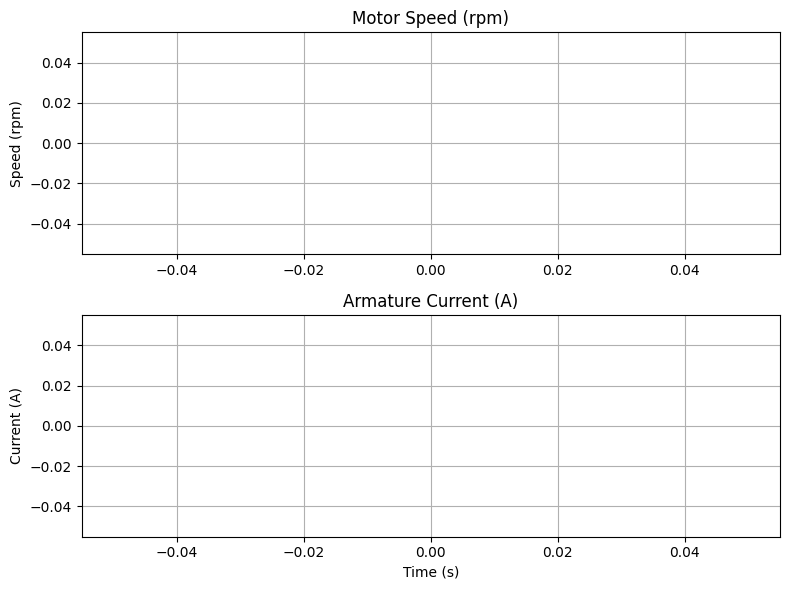

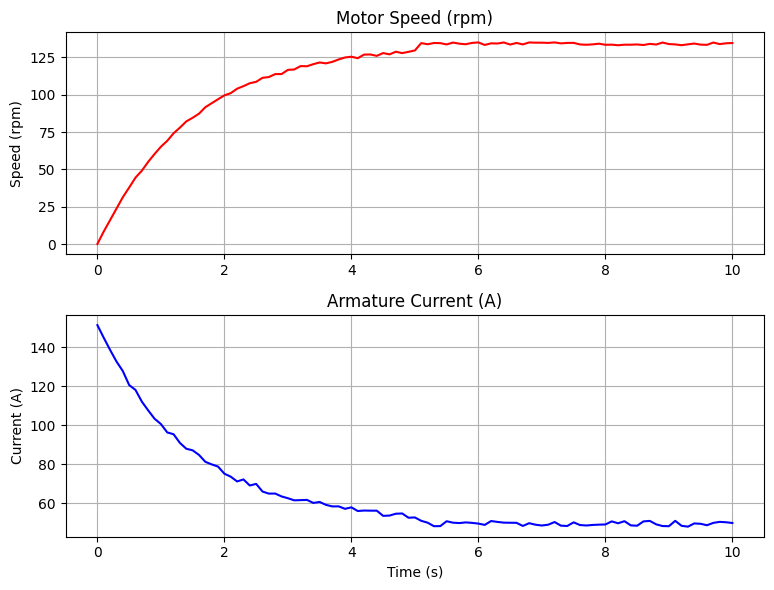

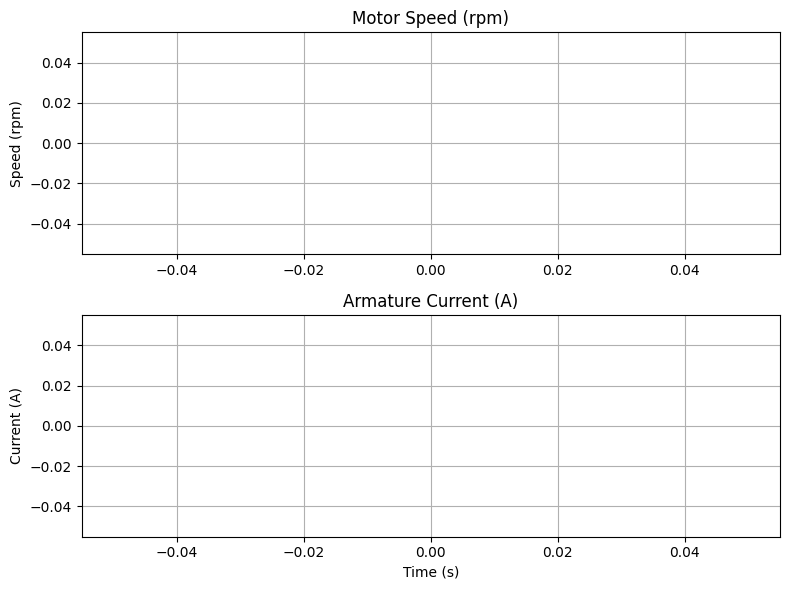

In [7]:
# Instantiate and display the ipywidgets application
app_widgets = MotorLabWidgetsApp()
display(app_widgets.get_app_widget())